In [46]:
# load GMM fit + matched-config SEAM k-means; compute per-cluster summary stats (no cluster matching)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

seam_dir = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
peak = "peak26256"
lib  = "100k"                                          # "100k" | "200k" | "300k"
K    = 100                                             # GMM cluster count (== SEAM kmeans count)
suffix = {"100k": "", "200k": "_200k", "300k": "_300k"}[lib]
seam_cfg = f"foregrounds{suffix}_kmeans{K}"            # matched-K SEAM run

# GMM fit (cached by bg_gmm.ipynb)
g = np.load(f"{seam_dir}/gmm_fits/{peak}.{lib}.K{K}.seed0.npz")
mu_fg, Nk = g["mu_fg"], g["Nk"]                        # foreground deviations (K,D), soft occupancy (K,)

# SEAM k-means cluster means/backgrounds/occupancy
seam_pk   = f"{seam_dir}/{seam_cfg}/{peak}"
seam_fg   = (np.load(f"{seam_pk}/cluster_maps.npy") - np.load(f"{seam_pk}/cluster_backgrounds.npy")).reshape(K, -1)
seam_n    = np.bincount(np.load(f"{seam_pk}/cluster_labels.npy"), minlength=K)

# per-cluster foreground strength = L2 norm of the background-subtracted mean map (no matching needed)
gmm_fg_norm  = np.linalg.norm(mu_fg, axis=1)
seam_fg_norm = np.linalg.norm(seam_fg, axis=1)

In [47]:
# side-by-side summary stats of the two clusterings (no cluster matching)
summary = pd.DataFrame([
    {"set": "GMM",  "n_nonempty": int((Nk >= 1).sum()),  "occ_min": int(Nk[Nk >= 1].min()),
     "occ_med": int(np.median(Nk[Nk >= 1])), "occ_max": int(Nk.max()),
     "fgnorm_mean": gmm_fg_norm.mean(),  "fgnorm_med": np.median(gmm_fg_norm)},
    {"set": "SEAM", "n_nonempty": int((seam_n >= 1).sum()), "occ_min": int(seam_n[seam_n >= 1].min()),
     "occ_med": int(np.median(seam_n[seam_n >= 1])), "occ_max": int(seam_n.max()),
     "fgnorm_mean": seam_fg_norm.mean(), "fgnorm_med": np.median(seam_fg_norm)},
]).set_index("set").round(3)
print(f"{peak}  |  lib {lib}  |  K={K}  |  GMM vs SEAM {seam_cfg}")
summary

peak26256  |  lib 100k  |  K=100  |  GMM vs SEAM foregrounds_kmeans100


,n_nonempty,occ_min,occ_med,occ_max,fgnorm_mean,fgnorm_med
set,,,,,,
GMM,100,1,1023,2085,1.444,1.397
SEAM,100,214,822,8540,1.804,1.694


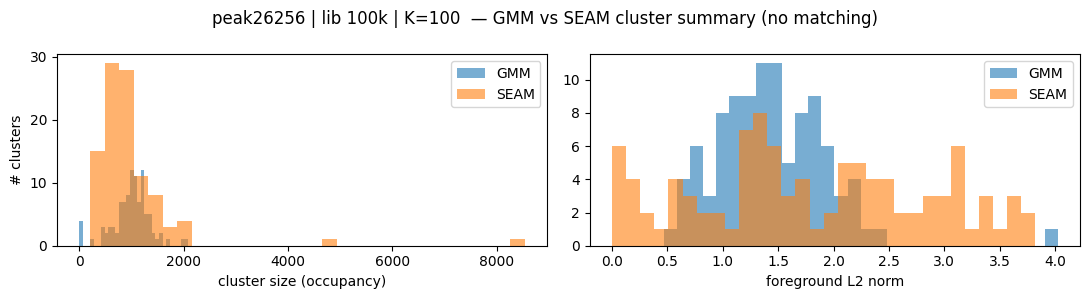

In [48]:
# compare the two clusterings' distributions: cluster size and foreground strength (no matching)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(Nk[Nk >= 1], bins=30, alpha=.6, label="GMM")
ax[0].hist(seam_n[seam_n >= 1], bins=30, alpha=.6, label="SEAM")
ax[0].set_xlabel("cluster size (occupancy)"); ax[0].set_ylabel("# clusters"); ax[0].legend()
ax[1].hist(gmm_fg_norm, bins=30, alpha=.6, label="GMM")
ax[1].hist(seam_fg_norm, bins=30, alpha=.6, label="SEAM")
ax[1].set_xlabel("foreground L2 norm"); ax[1].legend()
fig.suptitle(f"{peak} | lib {lib} | K={K}  — GMM vs SEAM cluster summary (no matching)")
plt.tight_layout(); plt.show()

within-cluster cosine to cluster mean:  GMM 0.705  |  SEAM 0.743


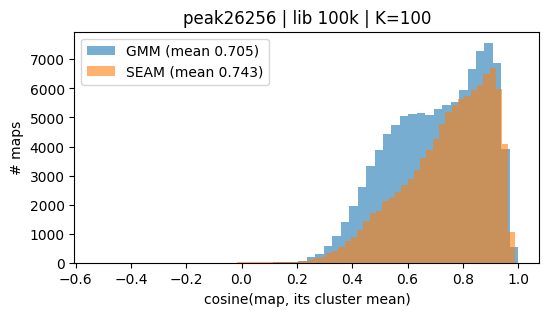

In [49]:
# within-cluster coherence: cosine of each attribution map to its own cluster's average logo
import h5py
with h5py.File(f"{seam_dir}/ism{suffix}/{peak}.h5") as f:
    X = f["ism_centered"][:].reshape(-1, mu_fg.shape[1])      # (N, 800) the maps both methods clustered
Xn = X / np.linalg.norm(X, axis=1, keepdims=True)

# GMM: centroid = empirical mean of the maps hard-assigned to each component (no bg)
gmm_labels = g["log_r"].argmax(1)
gmm_means = np.stack([X[gmm_labels == k].mean(0) if (gmm_labels == k).any()
                      else np.zeros(X.shape[1]) for k in range(K)])
gmm_means /= np.linalg.norm(gmm_means, axis=1, keepdims=True) + 1e-12
gmm_cos = (Xn * gmm_means[gmm_labels]).sum(1)

# SEAM: centroid = empirical mean of the maps in each k-means cluster (rebuilt from labels)
seam_labels = np.load(f"{seam_pk}/cluster_labels.npy")
seam_means = np.stack([X[seam_labels == k].mean(0) for k in range(K)])
seam_means /= np.linalg.norm(seam_means, axis=1, keepdims=True)
seam_cos = (Xn * seam_means[seam_labels]).sum(1)

print(f"within-cluster cosine to cluster mean:  GMM {gmm_cos.mean():.3f}  |  SEAM {seam_cos.mean():.3f}")
plt.figure(figsize=(6, 3))
plt.hist(gmm_cos,  bins=50, alpha=.6, label=f"GMM (mean {gmm_cos.mean():.3f})")
plt.hist(seam_cos, bins=50, alpha=.6, label=f"SEAM (mean {seam_cos.mean():.3f})")
plt.xlabel("cosine(map, its cluster mean)"); plt.ylabel("# maps"); plt.legend()
plt.title(f"{peak} | lib {lib} | K={K}")
plt.show()

within-cluster per-position Pearson r:  GMM 0.705  |  SEAM 0.747


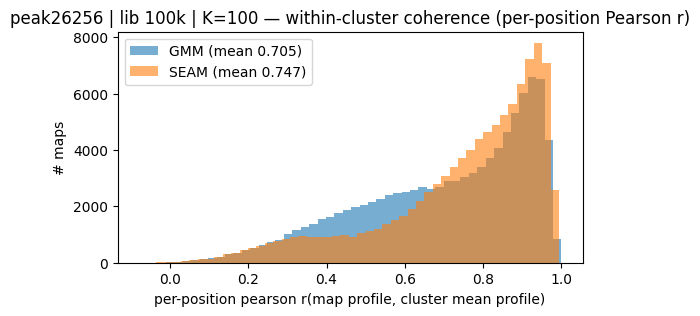

In [50]:
# per-position coherence: Pearson r between each map's positional importance profile and its cluster mean's
# (profile = per-position L2 magnitude over the 4 channels; correlation taken over the 200 positions)
def pos_profile(v):                                    # (M, 800) signed maps -> (M, 200) per-position magnitude
    return np.linalg.norm(v.reshape(v.shape[0], -1, 4), axis=2)

def pearson_pos(centers, assign):
    P  = pos_profile(X);       P  = P - P.mean(1, keepdims=True);  P  /= np.linalg.norm(P,  axis=1, keepdims=True)
    C  = pos_profile(centers); C  = C - C.mean(1, keepdims=True);  C  /= np.linalg.norm(C,  axis=1, keepdims=True)
    return (P * C[assign]).sum(1)

# GMM: centroid = empirical mean of the maps hard-assigned to each component (reuse gmm_means from cosine cell)
gmm_r = pearson_pos(gmm_means, gmm_labels)

# SEAM: centroid = empirical mean of the maps in each k-means cluster
seam_r = pearson_pos(seam_means, seam_labels)

print(f"within-cluster per-position Pearson r:  GMM {gmm_r.mean():.3f}  |  SEAM {seam_r.mean():.3f}")
plt.figure(figsize=(6, 3))
plt.hist(gmm_r,  bins=50, alpha=.6, label=f"GMM (mean {gmm_r.mean():.3f})")
plt.hist(seam_r, bins=50, alpha=.6, label=f"SEAM (mean {seam_r.mean():.3f})")
plt.xlabel("per-position pearson r(map profile, cluster mean profile)"); plt.ylabel("# maps"); plt.legend()
plt.title(f"{peak} | lib {lib} | K={K} — within-cluster coherence (per-position Pearson r)")
plt.show()